# UNIVERSIDAD AUTÓNOMA DE AGUASCALIENTES
## Departamento: Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente

**Curso:** Machine y Deep Learning  
**Maestro:** Dr. Francisco Javier Luna Rosas  
**Alumno:** Carlos Daniel Torres Macias
**Semestre:** Enero-Junio del 2026

---

# Práctica No. 36 – Descomposición de Componentes de Series de Tiempo y Regresión Lineal

En esta práctica se implementa la **descomposición de los cuatro componentes** de las series de tiempo obtenidas en la Práctica 32:

| Componente | Descripción |
|---|---|
| **Tendencia (T)** | Dirección general a largo plazo de la serie |
| **Ciclicidad (C)** | Fluctuaciones de largo plazo sin período fijo |
| **Estacionalidad (S)** | Patrones repetitivos con período fijo |
| **Movimiento Aleatorio (R)** | Variaciones irregulares no explicadas |

Adicionalmente se aplica **regresión lineal** a cada serie para modelar y proyectar la tendencia.

| # | Serie de Tiempo | Fuente |
|---|----------------|--------|
| 1 | Precio de cierre de Apple (AAPL) | Yahoo Finance |
| 2 | Precio de cierre de Tesla (TSLA) | Yahoo Finance |
| 3 | Precio del Bitcoin (BTC-USD) | Yahoo Finance |
| 4 | Tipo de cambio USD/MXN | Yahoo Finance |
| 5 | Precio del petróleo (Crude Oil Futures) | Yahoo Finance |

---
## Paso 1: Instalación e importación de librerías

In [1]:
# Instalar dependencias necesarias
!pip install yfinance statsmodels scikit-learn --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Descomposición de series de tiempo
from statsmodels.tsa.seasonal import seasonal_decompose

# Regresión lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Estilo visual
plt.style.use('seaborn-v0_8-darkgrid')
print('Librerías cargadas correctamente.')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Librerías cargadas correctamente.


---
## Paso 2: Descarga de las 5 series de tiempo desde Yahoo Finance
> Mismas series utilizadas en la Práctica 32 (período 2023-2025)

In [2]:
# Período de análisis: mismo que Práctica 32
inicio = '2023-01-01'
fin    = '2025-01-01'

# Diccionario: ticker -> nombre descriptivo
series = {
    'AAPL'   : 'Apple Inc. (AAPL)',
    'TSLA'   : 'Tesla Inc. (TSLA)',
    'BTC-USD': 'Bitcoin (BTC-USD)',
    'MXN=X'  : 'USD/MXN Tipo de Cambio',
    'CL=F'   : 'Petróleo Crudo (WTI Futures)'
}

datos = {}
for ticker, nombre in series.items():
    df = yf.download(ticker, start=inicio, end=fin, progress=False, auto_adjust=True)
    close = df['Close'].squeeze()
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.name = ticker
    # Rellenar NaN con interpolación lineal (necesario para descomposición)
    close = close.interpolate(method='linear').dropna()
    datos[ticker] = close
    print(f'{nombre}: {len(close)} observaciones descargadas')

print('\nDescarga completada.')

Apple Inc. (AAPL): 502 observaciones descargadas
Tesla Inc. (TSLA): 502 observaciones descargadas
Bitcoin (BTC-USD): 731 observaciones descargadas
USD/MXN Tipo de Cambio: 522 observaciones descargadas
Petróleo Crudo (WTI Futures): 502 observaciones descargadas

Descarga completada.


---
## Paso 3: Fundamento Teórico de la Descomposición

Una serie de tiempo $Y_t$ puede descomponerse en sus componentes fundamentales mediante dos modelos:

### Modelo Aditivo
$$Y_t = T_t + S_t + C_t + R_t$$

Adecuado cuando la **amplitud de la estacionalidad es constante** a lo largo del tiempo.

### Modelo Multiplicativo
$$Y_t = T_t \times S_t \times C_t \times R_t$$

Adecuado cuando la **amplitud de la estacionalidad crece proporcionalmente** con el nivel de la serie.

Donde:
- $T_t$ = **Tendencia**: dirección general de largo plazo
- $S_t$ = **Estacionalidad**: patrón repetitivo con período fijo
- $C_t$ = **Ciclicidad**: fluctuaciones de largo plazo sin período fijo
- $R_t$ = **Residuo/Aleatorio**: variaciones no explicadas por los demás componentes

> **Nota:** En datos diarios de mercados financieros se utiliza `period=30` (≈ 1 mes bursátil) o `period=252` (≈ 1 año bursátil). Para esta práctica se usa **period=30** para capturar patrones mensuales.

---
## Paso 4: Función auxiliar de descomposición y regresión

In [3]:
def descomponer_y_regresar(ticker, nombre, color, period=30, model='additive'):
    """
    Realiza la descomposición de componentes y regresión lineal
    para una serie de tiempo financiera.

    Parámetros:
    -----------
    ticker  : str   – clave del diccionario `datos`
    nombre  : str   – nombre descriptivo para títulos
    color   : str   – color base de la serie
    period  : int   – período de estacionalidad (default=30 días)
    model   : str   – 'additive' o 'multiplicative'

    Retorna:
    --------
    result  : DecomposeResult de statsmodels
    """
    serie = datos[ticker].dropna()

    # ── 1. DESCOMPOSICIÓN ────────────────────────────────────────────────────
    result = seasonal_decompose(serie, model=model, period=period,
                                extrapolate_trend='freq')

    fig, axes = plt.subplots(5, 1, figsize=(13, 16))
    fig.suptitle(
        f'Descomposición de Componentes – {nombre}\n'
        f'Modelo {model.capitalize()} | Período = {period} días',
        fontsize=14, fontweight='bold'
    )

    # Componente 0: Serie original
    axes[0].plot(serie.index, serie.values, color=color, linewidth=1.5)
    axes[0].fill_between(serie.index, serie.values, alpha=0.12, color=color)
    axes[0].set_title('Serie Original $Y_t$', fontweight='bold')
    axes[0].set_ylabel('Valor')

    # Componente 1: Tendencia
    axes[1].plot(result.trend.index, result.trend.values,
                 color='#1a1aff', linewidth=2)
    axes[1].set_title('Tendencia $T_t$', fontweight='bold')
    axes[1].set_ylabel('Valor')

    # Componente 2: Estacionalidad
    axes[2].plot(result.seasonal.index, result.seasonal.values,
                 color='#cc0099', linewidth=1.2)
    axes[2].axhline(0 if model == 'additive' else 1,
                    color='gray', linestyle='--', linewidth=0.8)
    axes[2].set_title('Estacionalidad $S_t$', fontweight='bold')
    axes[2].set_ylabel('Valor')

    # Componente 3: Ciclicidad (aproximada como tendencia suavizada)
    # Se estima aplicando una media móvil de largo plazo sobre la tendencia
    ciclo = result.trend.rolling(window=60, center=True, min_periods=1).mean()
    axes[3].plot(ciclo.index, ciclo.values, color='#00802b', linewidth=2)
    axes[3].set_title('Ciclicidad $C_t$ (media móvil 60 días sobre tendencia)',
                       fontweight='bold')
    axes[3].set_ylabel('Valor')

    # Componente 4: Residuo / Movimiento Aleatorio
    axes[4].plot(result.resid.index, result.resid.values,
                 color='#cc3300', linewidth=0.9, alpha=0.8)
    axes[4].axhline(0 if model == 'additive' else 1,
                    color='gray', linestyle='--', linewidth=0.8)
    axes[4].set_title('Movimiento Aleatorio / Residuo $R_t$', fontweight='bold')
    axes[4].set_ylabel('Valor')

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', labelsize=8)

    plt.tight_layout()
    fname = f'decomp_{ticker.replace("-","").replace("=","")}.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Descomposición guardada: {fname}')

    # ── 2. REGRESIÓN LINEAL ──────────────────────────────────────────────────
    # Variable independiente: índice numérico (días desde el inicio)
    X = np.arange(len(serie)).reshape(-1, 1)
    y = serie.values

    modelo_lr = LinearRegression()
    modelo_lr.fit(X, y)
    y_pred = modelo_lr.predict(X)

    # Proyección a 180 días futuros
    X_fut = np.arange(len(serie), len(serie) + 180).reshape(-1, 1)
    y_fut = modelo_lr.predict(X_fut)

    # Fechas futuras (días hábiles aproximados)
    ultima_fecha = serie.index[-1]
    fechas_futuras = pd.bdate_range(start=ultima_fecha + pd.Timedelta(days=1),
                                    periods=180)

    r2  = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)

    # Gráfica de regresión
    fig2, ax2 = plt.subplots(figsize=(13, 5))
    ax2.plot(serie.index, y, color=color, linewidth=1.5,
             alpha=0.8, label='Serie original')
    ax2.plot(serie.index, y_pred, color='#1a1aff', linewidth=2,
             linestyle='--', label=f'Regresión lineal (R²={r2:.4f})')
    ax2.plot(fechas_futuras[:len(y_fut)], y_fut, color='#ff6600',
             linewidth=2, linestyle=':', label='Proyección 180 días')
    ax2.axvline(ultima_fecha, color='gray', linewidth=1,
                linestyle='--', alpha=0.6, label='Inicio proyección')

    pendiente_signo = '↑' if modelo_lr.coef_[0] > 0 else '↓'
    ax2.set_title(
        f'Regresión Lineal – {nombre}\n'
        f'Pendiente: {modelo_lr.coef_[0]:.4f} {pendiente_signo}  |  '
        f'Intercepto: {modelo_lr.intercept_:.2f}  |  '
        f'R²: {r2:.4f}  |  RMSE: {rmse:.2f}',
        fontsize=12, fontweight='bold'
    )
    ax2.set_xlabel('Fecha')
    ax2.set_ylabel('Precio / Valor')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.legend(fontsize=9)
    plt.tight_layout()
    fname2 = f'regresion_{ticker.replace("-","").replace("=","")}.png'
    plt.savefig(fname2, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Regresión guardada: {fname2}')

    # Tabla resumen
    print(f'\n  ┌─ Estadísticas de Regresión Lineal – {nombre}')
    print(f'  │  Pendiente  (β₁): {modelo_lr.coef_[0]:>12.6f}')
    print(f'  │  Intercepto (β₀): {modelo_lr.intercept_:>12.4f}')
    print(f'  │  R²              : {r2:>12.6f}')
    print(f'  │  RMSE            : {rmse:>12.4f}')
    print(f'  └─────────────────────────────────────────────\n')

    return result, modelo_lr

print('Función auxiliar definida.')

Función auxiliar definida.


---
## Serie 1: Apple Inc. (AAPL) – Descomposición y Regresión

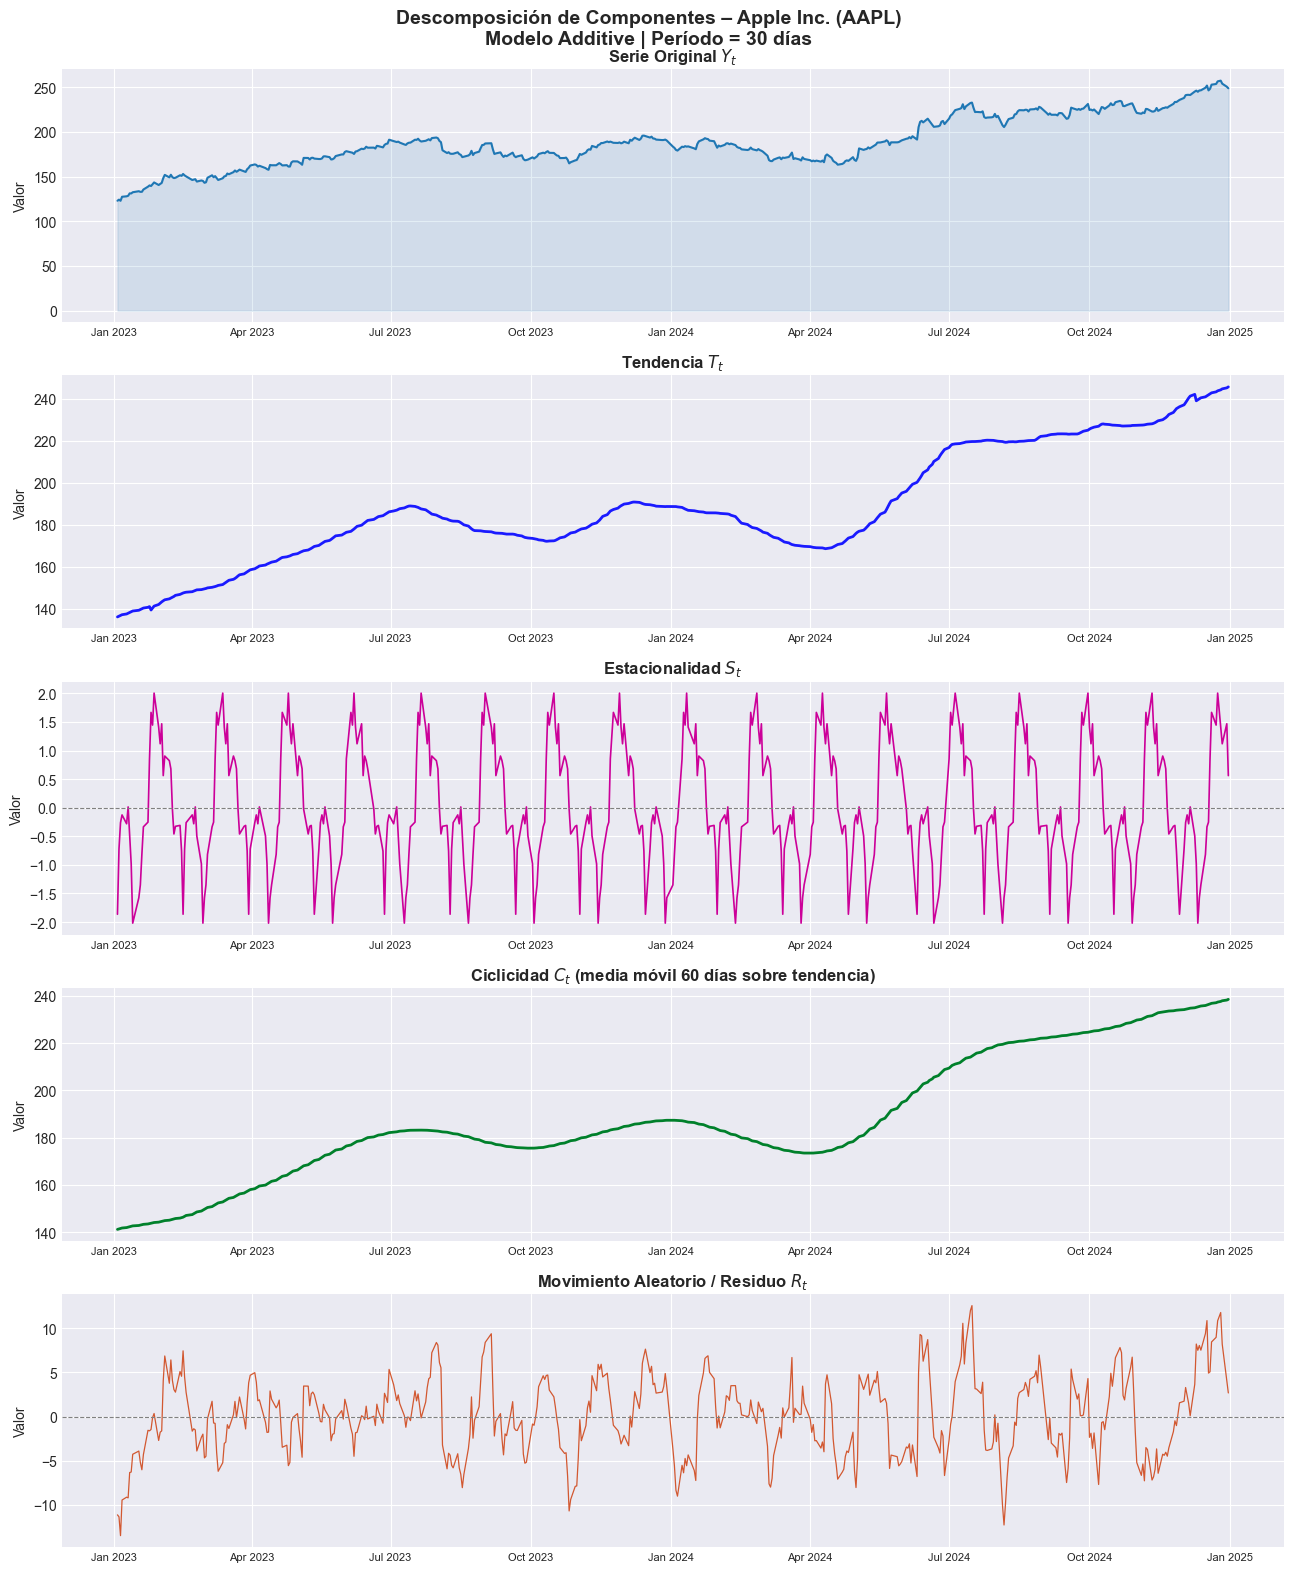

Descomposición guardada: decomp_AAPL.png


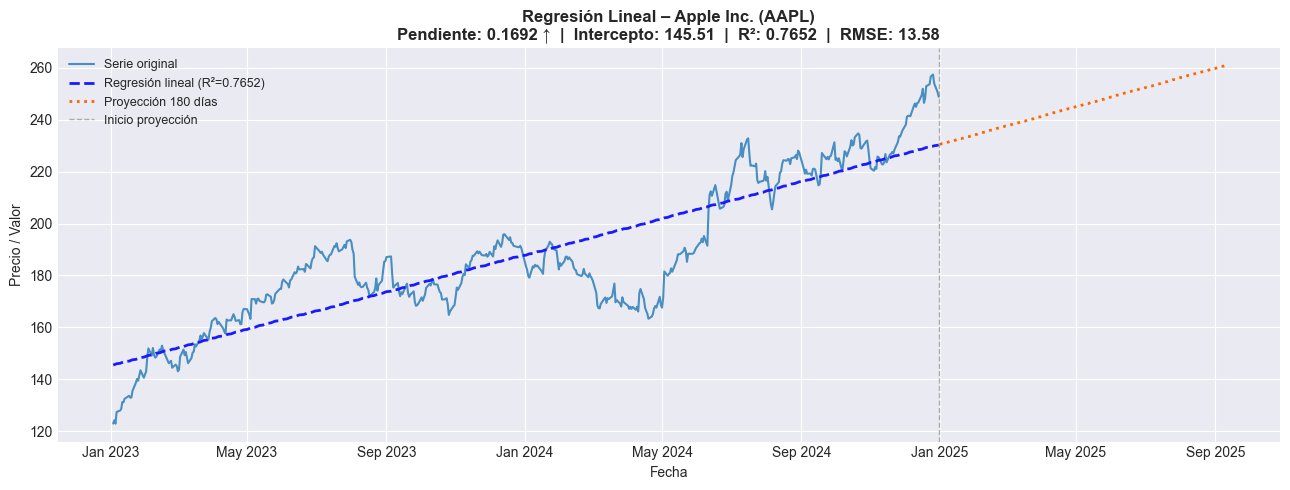

Regresión guardada: regresion_AAPL.png

  ┌─ Estadísticas de Regresión Lineal – Apple Inc. (AAPL)
  │  Pendiente  (β₁):     0.169225
  │  Intercepto (β₀):     145.5053
  │  R²              :     0.765211
  │  RMSE            :      13.5839
  └─────────────────────────────────────────────



In [4]:
result_aapl, lr_aapl = descomponer_y_regresar(
    ticker='AAPL',
    nombre='Apple Inc. (AAPL)',
    color='#1f77b4',
    period=30,
    model='additive'
)

---
## Serie 2: Tesla Inc. (TSLA) – Descomposición y Regresión

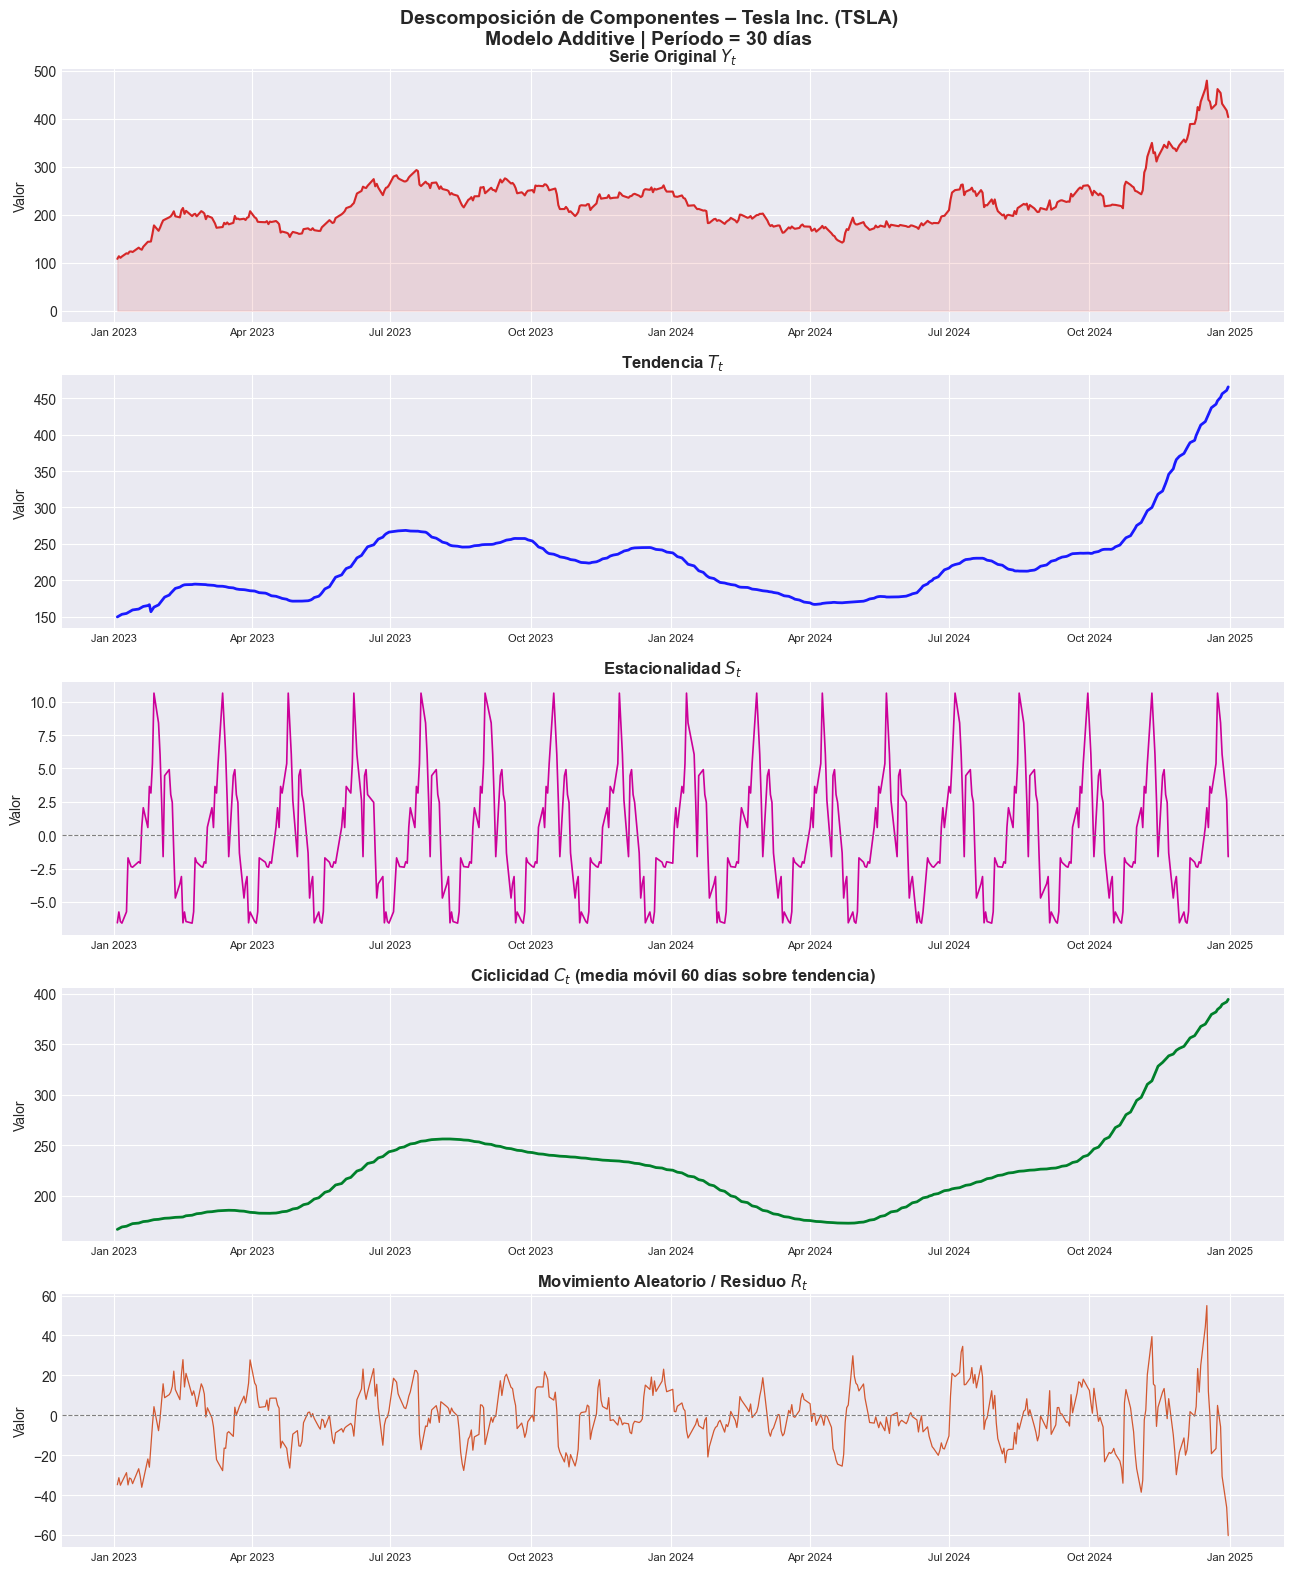

Descomposición guardada: decomp_TSLA.png


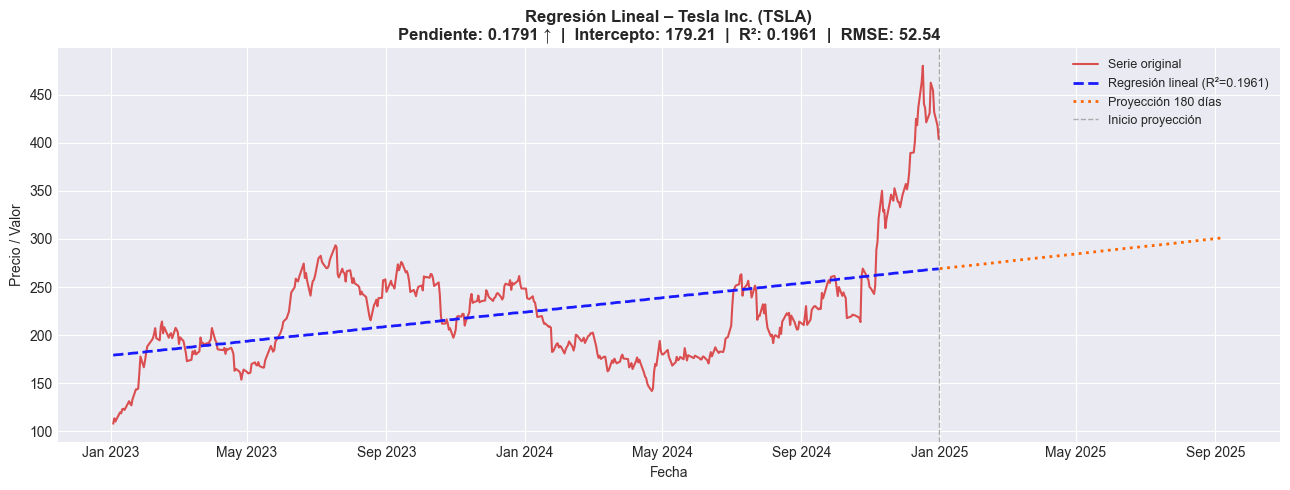

Regresión guardada: regresion_TSLA.png

  ┌─ Estadísticas de Regresión Lineal – Tesla Inc. (TSLA)
  │  Pendiente  (β₁):     0.179093
  │  Intercepto (β₀):     179.2085
  │  R²              :     0.196121
  │  RMSE            :      52.5441
  └─────────────────────────────────────────────



In [5]:
result_tsla, lr_tsla = descomponer_y_regresar(
    ticker='TSLA',
    nombre='Tesla Inc. (TSLA)',
    color='#d62728',
    period=30,
    model='additive'
)

---
## Serie 3: Bitcoin (BTC-USD) – Descomposición y Regresión

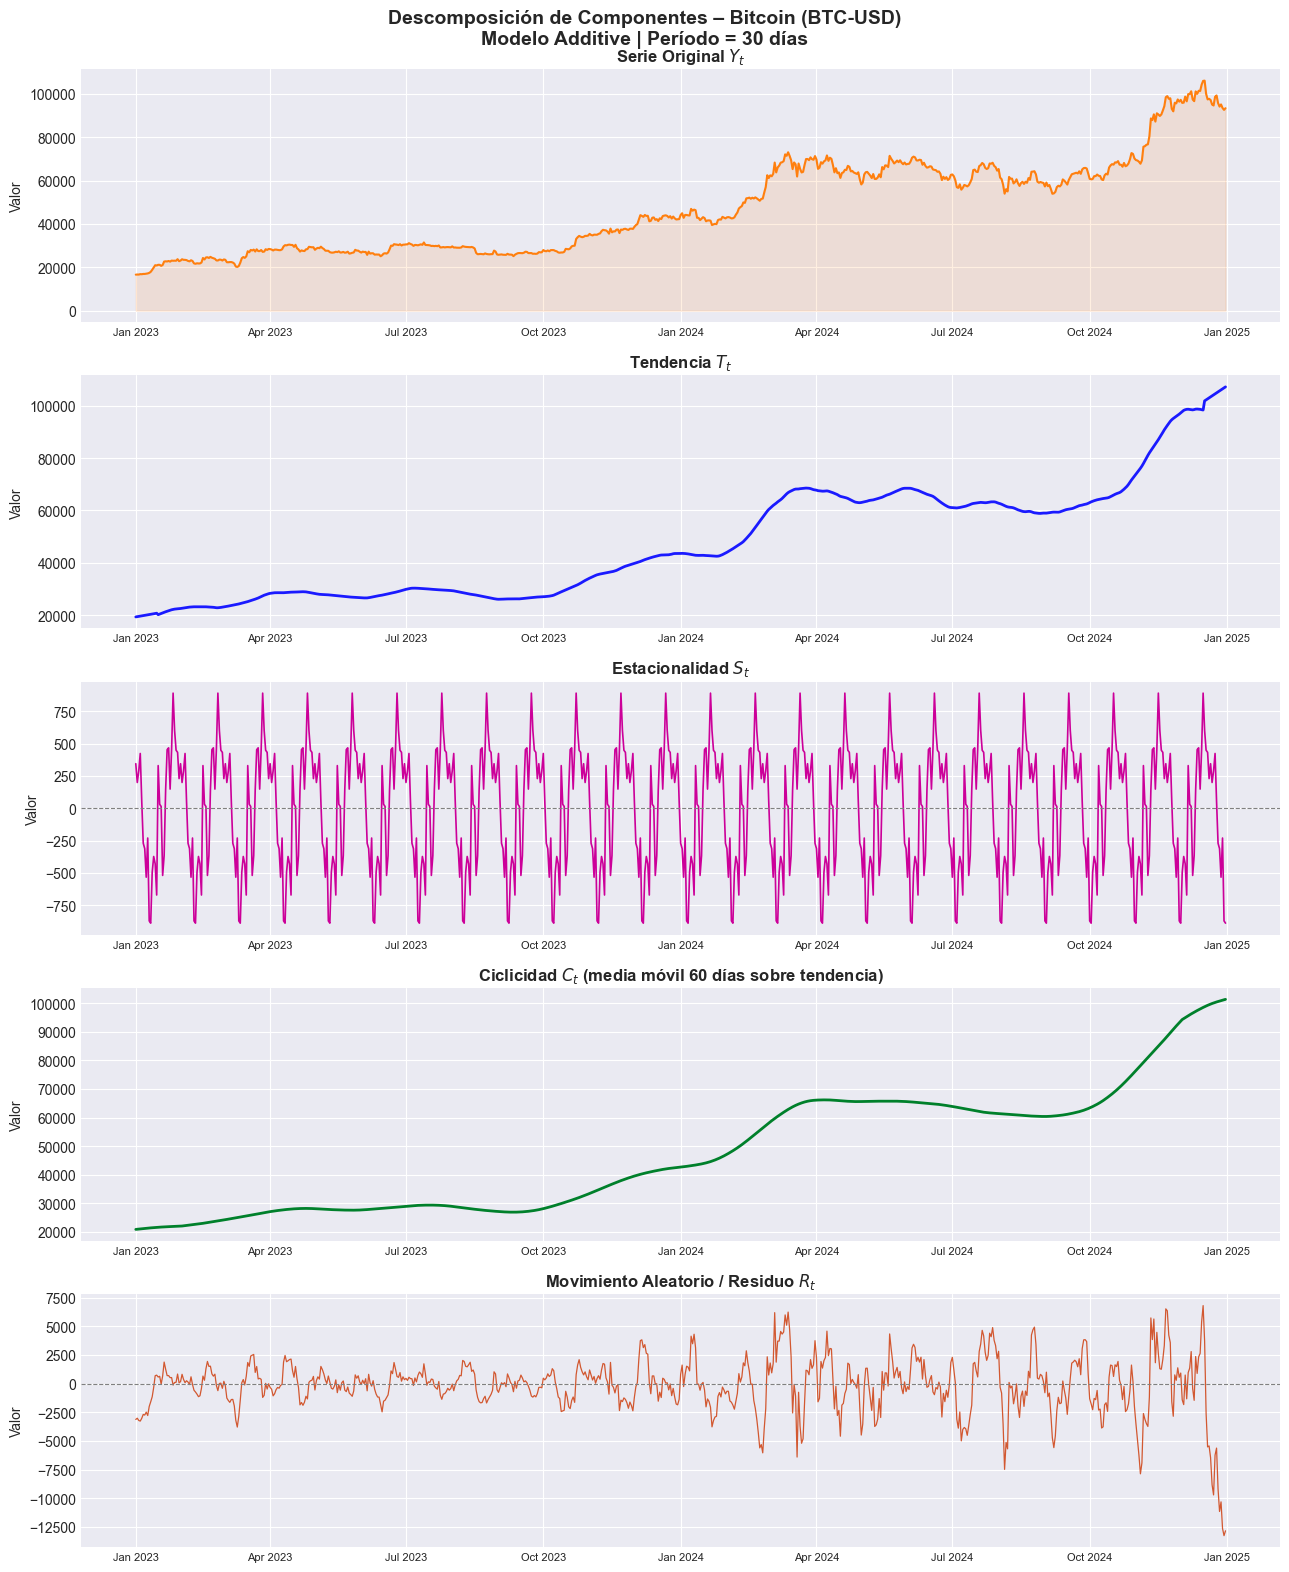

Descomposición guardada: decomp_BTCUSD.png


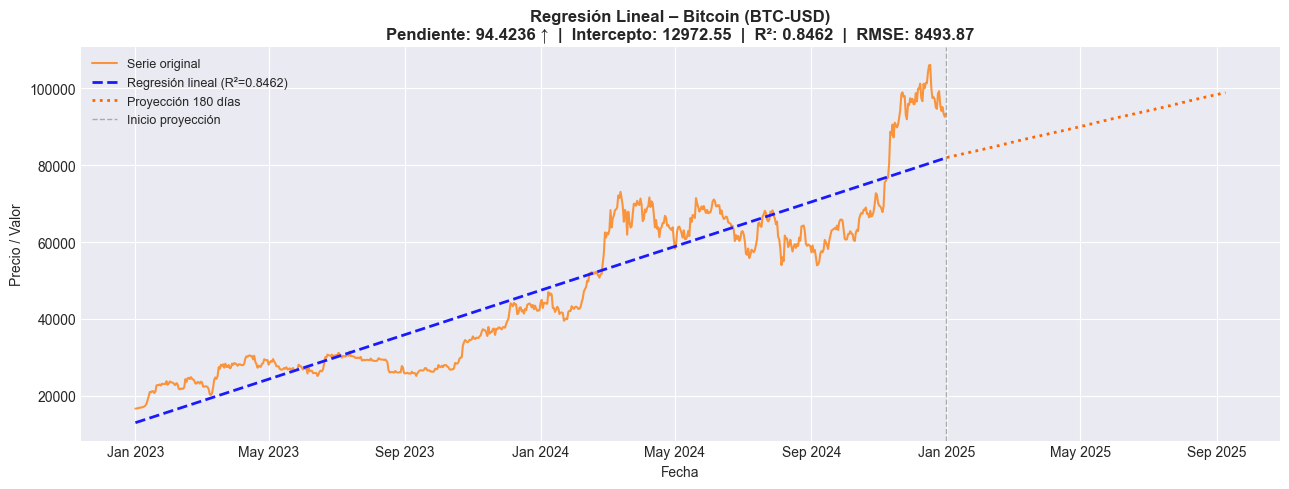

Regresión guardada: regresion_BTCUSD.png

  ┌─ Estadísticas de Regresión Lineal – Bitcoin (BTC-USD)
  │  Pendiente  (β₁):    94.423581
  │  Intercepto (β₀):   12972.5540
  │  R²              :     0.846226
  │  RMSE            :    8493.8714
  └─────────────────────────────────────────────



In [6]:
result_btc, lr_btc = descomponer_y_regresar(
    ticker='BTC-USD',
    nombre='Bitcoin (BTC-USD)',
    color='#ff7f0e',
    period=30,
    model='additive'
)

---
## Serie 4: USD/MXN – Descomposición y Regresión

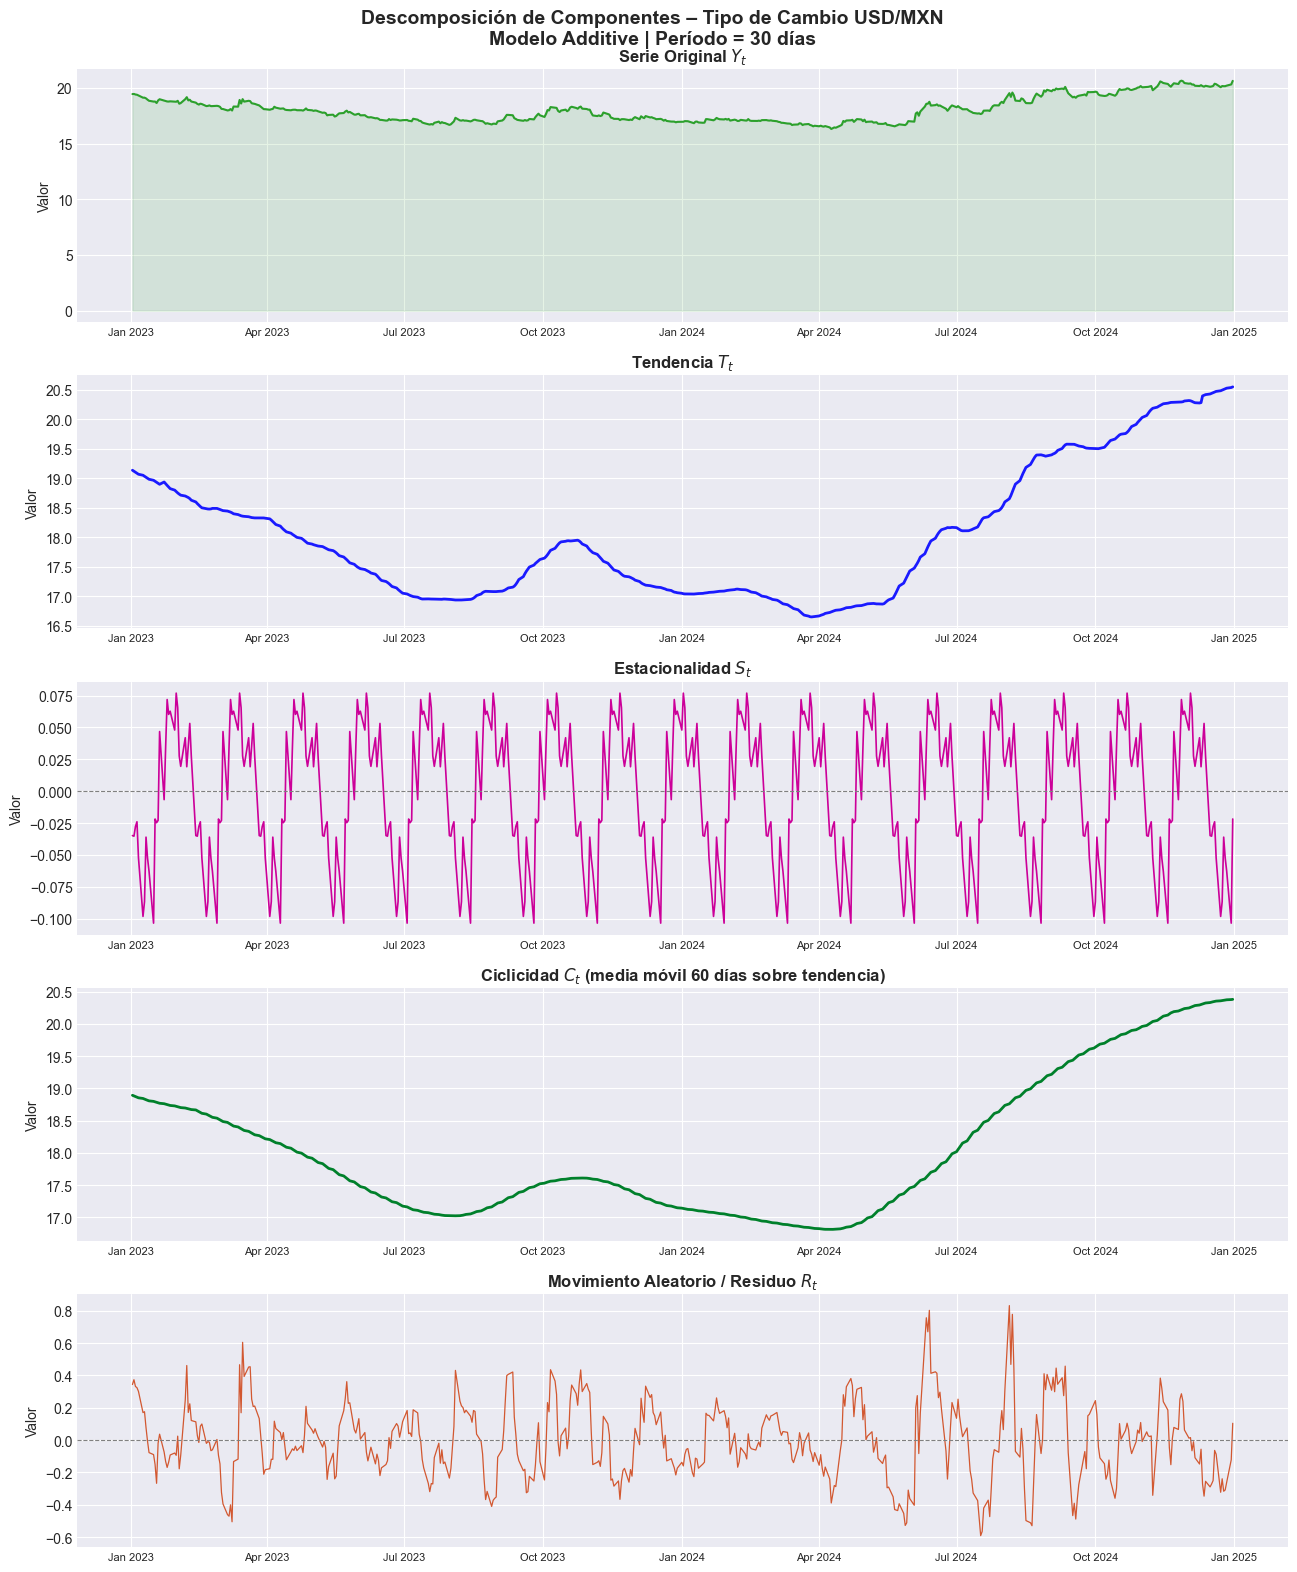

Descomposición guardada: decomp_MXNX.png


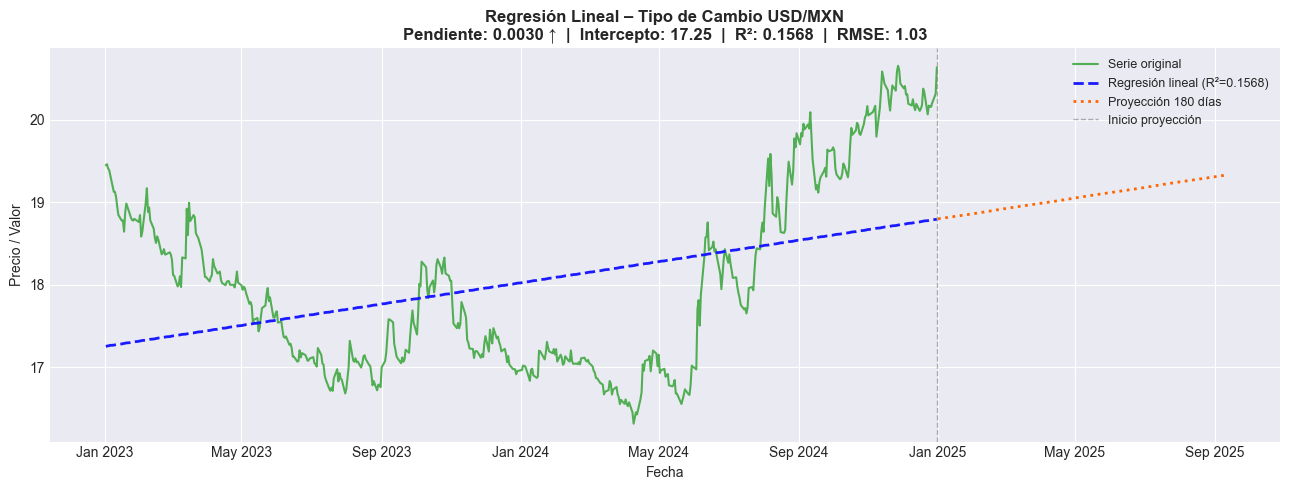

Regresión guardada: regresion_MXNX.png

  ┌─ Estadísticas de Regresión Lineal – Tipo de Cambio USD/MXN
  │  Pendiente  (β₁):     0.002957
  │  Intercepto (β₀):      17.2517
  │  R²              :     0.156847
  │  RMSE            :       1.0333
  └─────────────────────────────────────────────



In [7]:
result_mxn, lr_mxn = descomponer_y_regresar(
    ticker='MXN=X',
    nombre='Tipo de Cambio USD/MXN',
    color='#2ca02c',
    period=30,
    model='additive'
)

---
## Serie 5: Petróleo Crudo WTI (CL=F) – Descomposición y Regresión

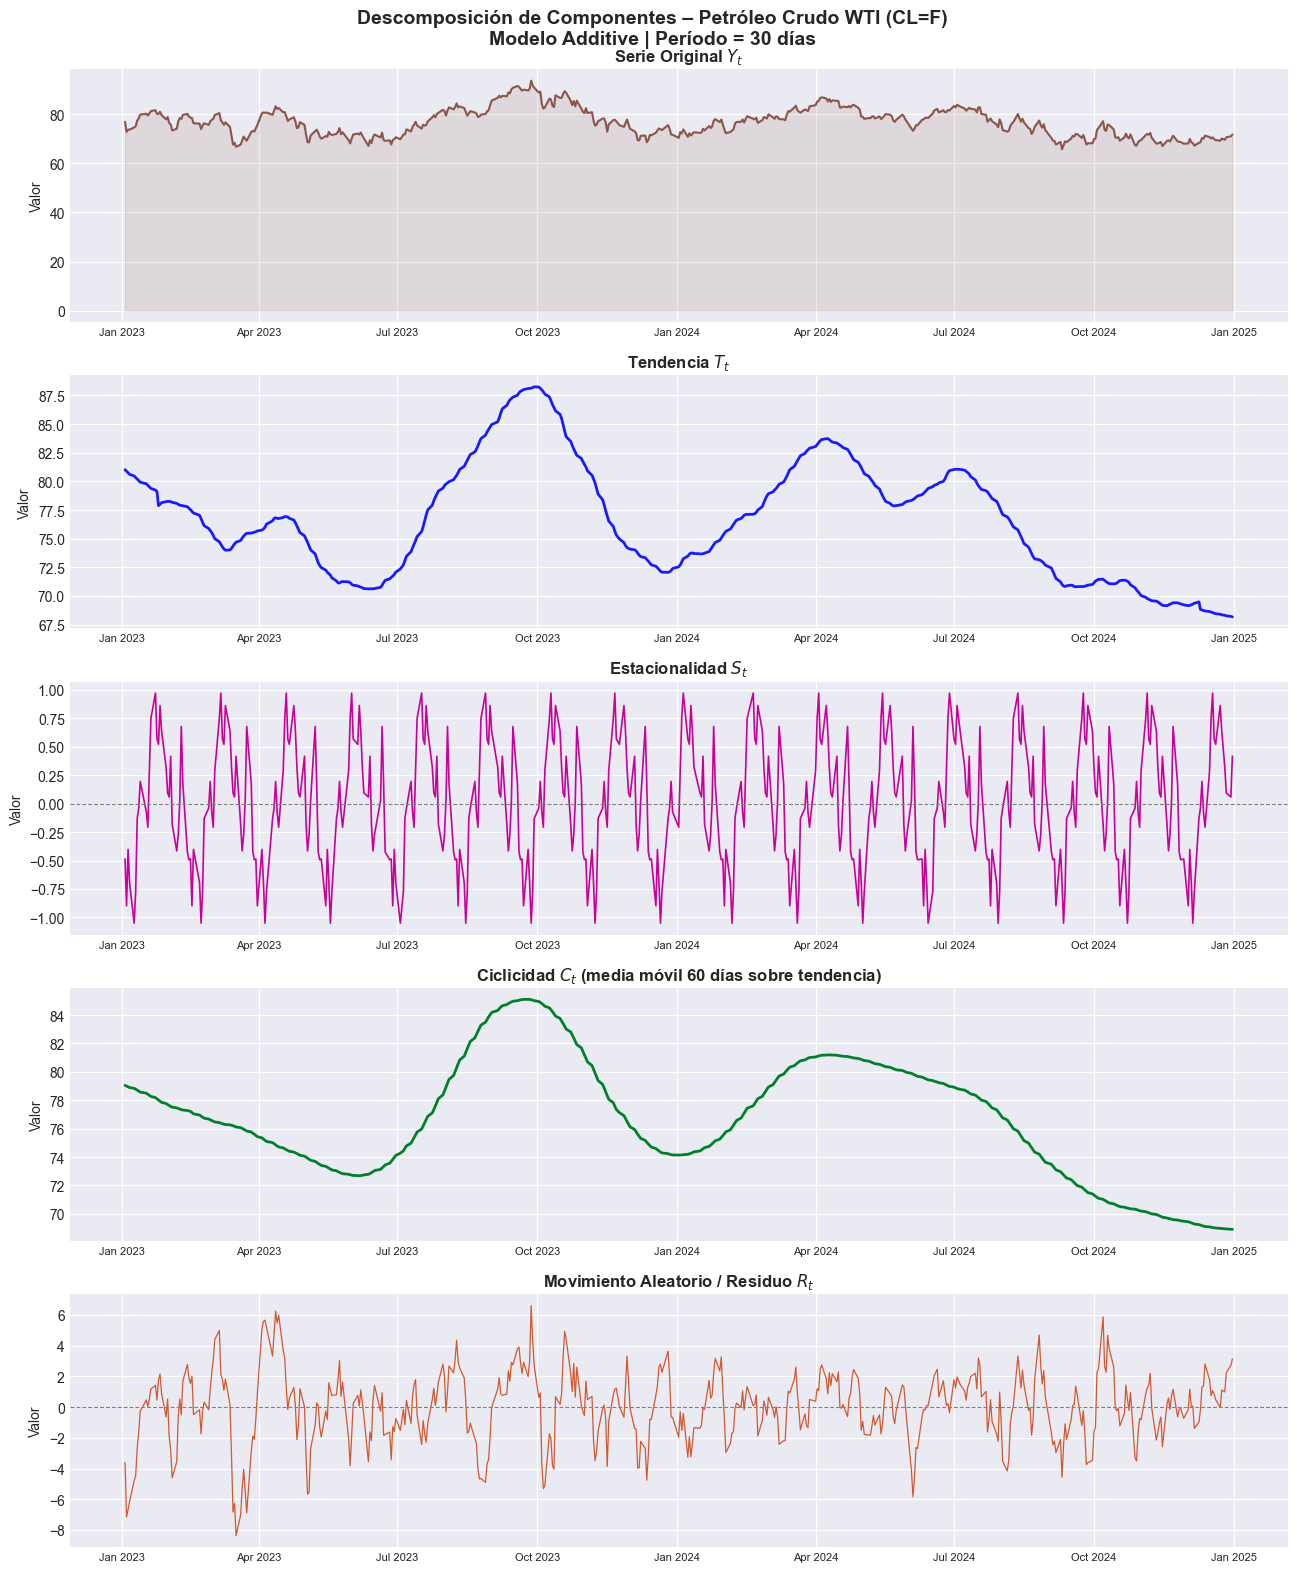

Descomposición guardada: decomp_CLF.png


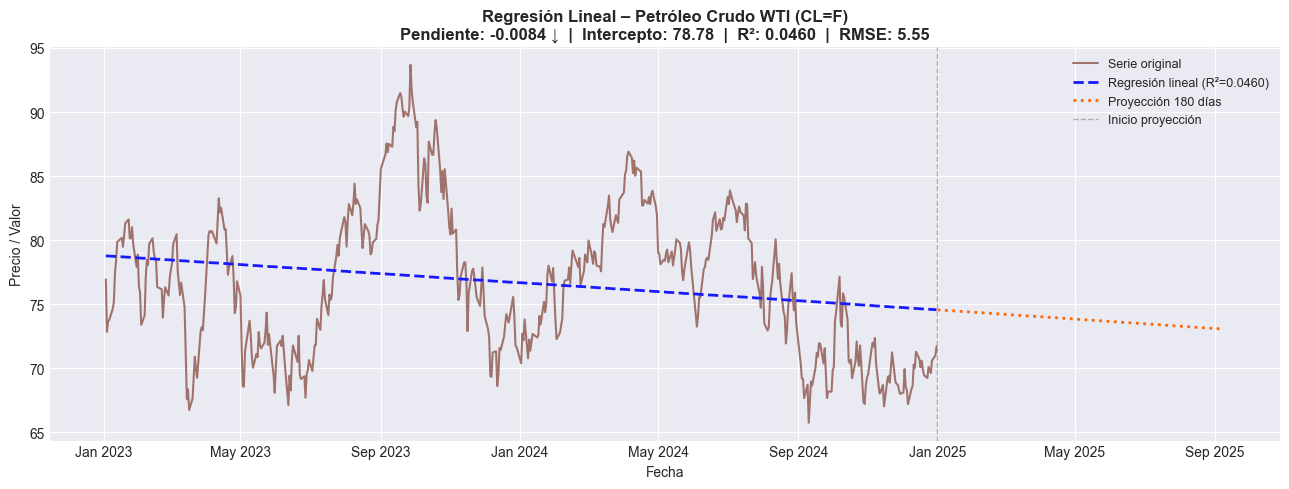

Regresión guardada: regresion_CLF.png

  ┌─ Estadísticas de Regresión Lineal – Petróleo Crudo WTI (CL=F)
  │  Pendiente  (β₁):    -0.008401
  │  Intercepto (β₀):      78.7784
  │  R²              :     0.045964
  │  RMSE            :       5.5467
  └─────────────────────────────────────────────



In [8]:
result_oil, lr_oil = descomponer_y_regresar(
    ticker='CL=F',
    nombre='Petróleo Crudo WTI (CL=F)',
    color='#8c564b',
    period=30,
    model='additive'
)

---
## Paso 5: Tabla Comparativa de Regresión Lineal – 5 Series

In [9]:
from sklearn.metrics import r2_score

modelos = {
    'Apple (AAPL)'       : lr_aapl,
    'Tesla (TSLA)'       : lr_tsla,
    'Bitcoin (BTC-USD)'  : lr_btc,
    'USD/MXN'            : lr_mxn,
    'Petróleo WTI (CL=F)': lr_oil,
}

tickers_list = ['AAPL', 'TSLA', 'BTC-USD', 'MXN=X', 'CL=F']

filas = []
for (nombre, modelo), ticker in zip(modelos.items(), tickers_list):
    serie = datos[ticker].dropna()
    X = np.arange(len(serie)).reshape(-1, 1)
    y = serie.values
    y_pred = modelo.predict(X)
    r2   = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    tendencia = '↑ Alcista' if modelo.coef_[0] > 0 else '↓ Bajista'
    filas.append({
        'Serie': nombre,
        'Pendiente (β₁)': round(modelo.coef_[0], 6),
        'Intercepto (β₀)': round(modelo.intercept_, 2),
        'R²': round(r2, 4),
        'RMSE': round(rmse, 4),
        'Tendencia': tendencia
    })

df_resumen = pd.DataFrame(filas).set_index('Serie')
print('\nTABLA COMPARATIVA – REGRESIÓN LINEAL (5 SERIES)')
print('=' * 75)
display(df_resumen)
print('=' * 75)


TABLA COMPARATIVA – REGRESIÓN LINEAL (5 SERIES)


,Pendiente (β₁),Intercepto (β₀),R²,RMSE,Tendencia
Serie,,,,,
Apple (AAPL),0.169225,145.51,0.7652,13.5839,↑ Alcista
Tesla (TSLA),0.179093,179.21,0.1961,52.5441,↑ Alcista
Bitcoin (BTC-USD),94.423581,12972.55,0.8462,8493.8714,↑ Alcista
USD/MXN,0.002957,17.25,0.1568,1.0333,↑ Alcista
Petróleo WTI (CL=F),-0.008401,78.78,0.0460,5.5467,↓ Bajista


---
## Paso 6: Panel comparativo de Tendencias – 5 Series

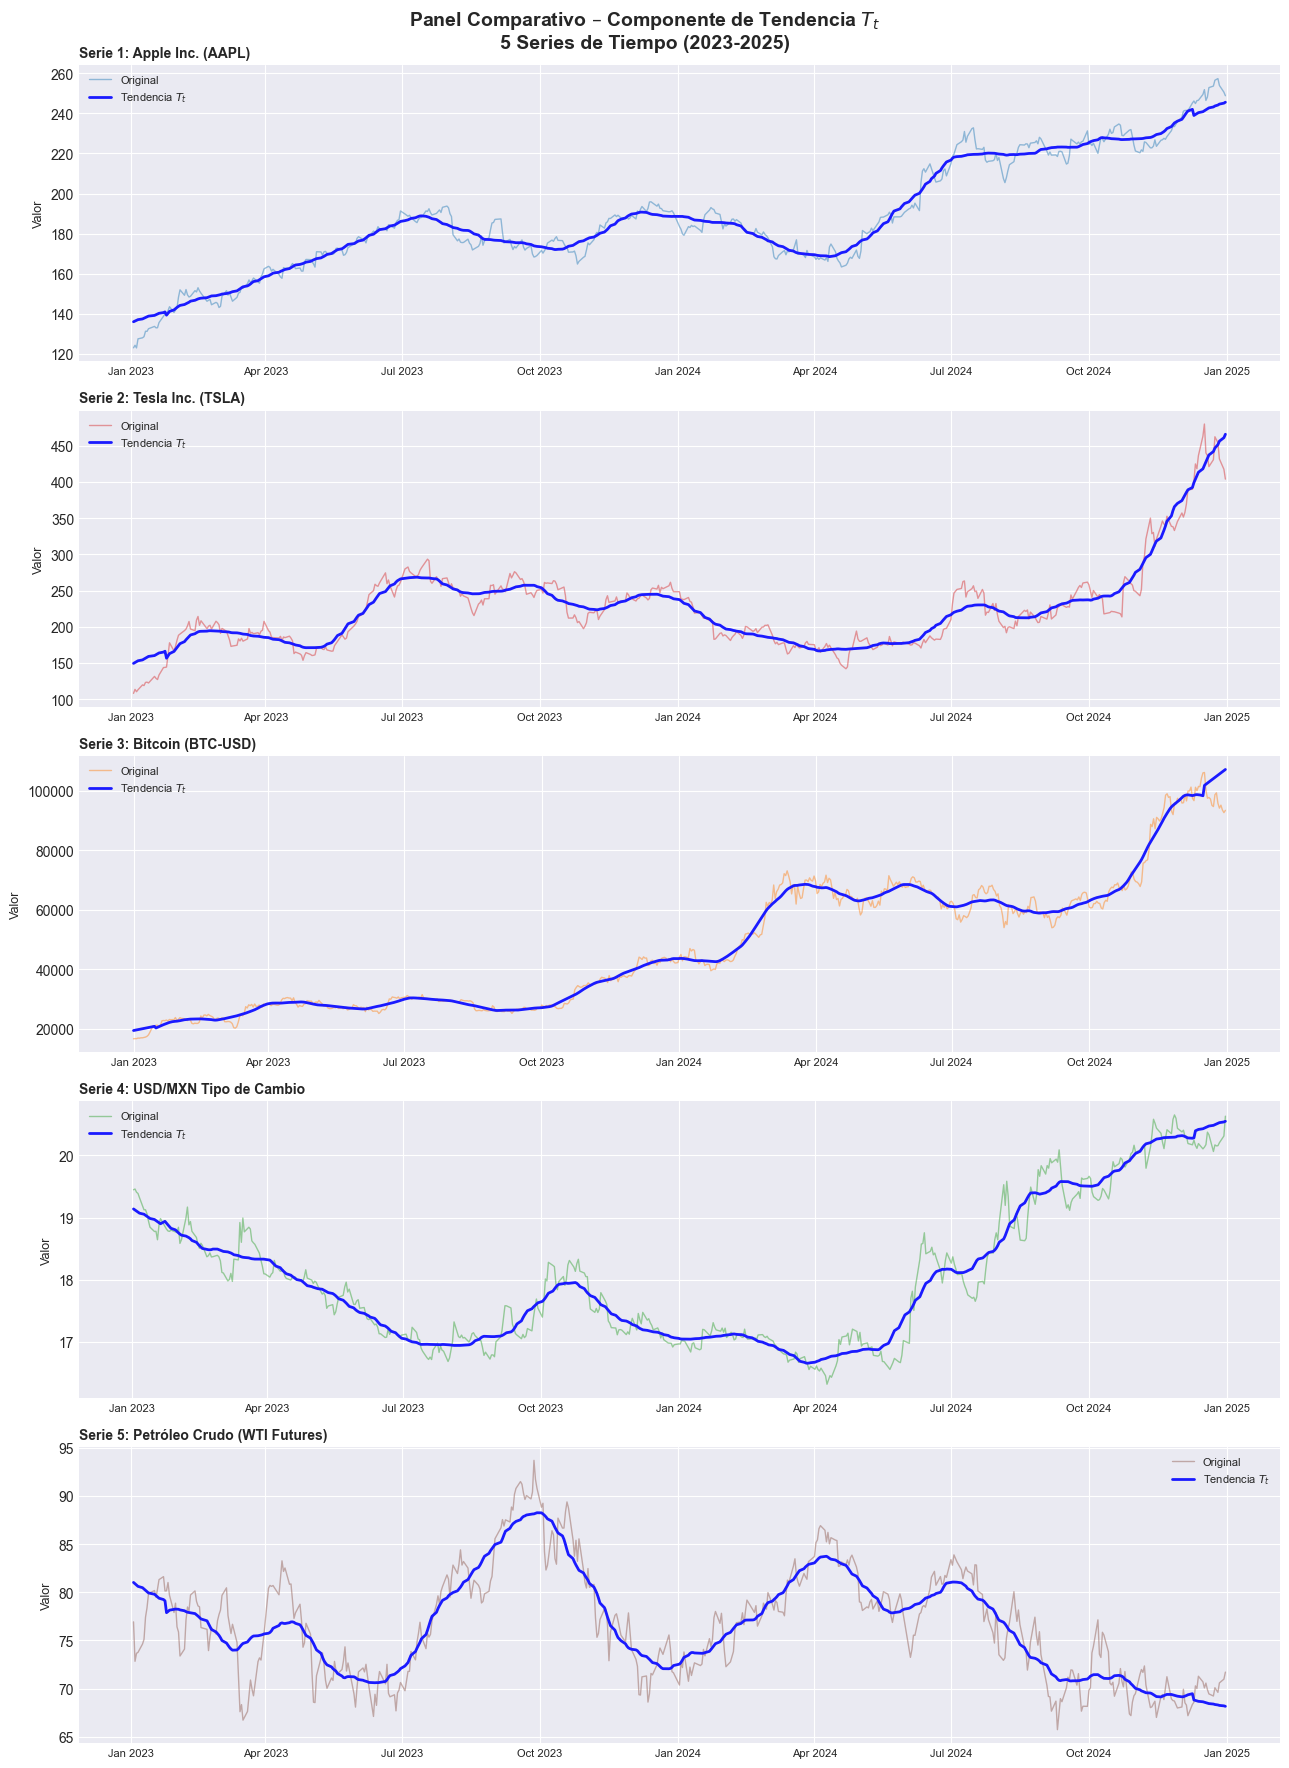

Panel de tendencias guardado: panel_tendencias.png


In [10]:
colores   = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c', '#8c564b']
tickers_l = ['AAPL', 'TSLA', 'BTC-USD', 'MXN=X', 'CL=F']
nombres_l = list(series.values())
results_l = [result_aapl, result_tsla, result_btc, result_mxn, result_oil]

fig, axes = plt.subplots(5, 1, figsize=(13, 18), sharex=False)
fig.suptitle(
    'Panel Comparativo – Componente de Tendencia $T_t$\n'
    '5 Series de Tiempo (2023-2025)',
    fontsize=14, fontweight='bold'
)

for i, (ticker, nombre, color, res, ax) in enumerate(
        zip(tickers_l, nombres_l, colores, results_l, axes)):
    serie = datos[ticker].dropna()
    ax.plot(serie.index, serie.values, color=color,
            linewidth=1, alpha=0.45, label='Original')
    ax.plot(res.trend.index, res.trend.values, color='#1a1aff',
            linewidth=2, label='Tendencia $T_t$')
    ax.set_title(f'Serie {i+1}: {nombre}', fontsize=10,
                 fontweight='bold', loc='left')
    ax.set_ylabel('Valor', fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('panel_tendencias.png', dpi=130, bbox_inches='tight')
plt.show()
print('Panel de tendencias guardado: panel_tendencias.png')

---
## Paso 7: Panel comparativo de Residuos / Movimiento Aleatorio

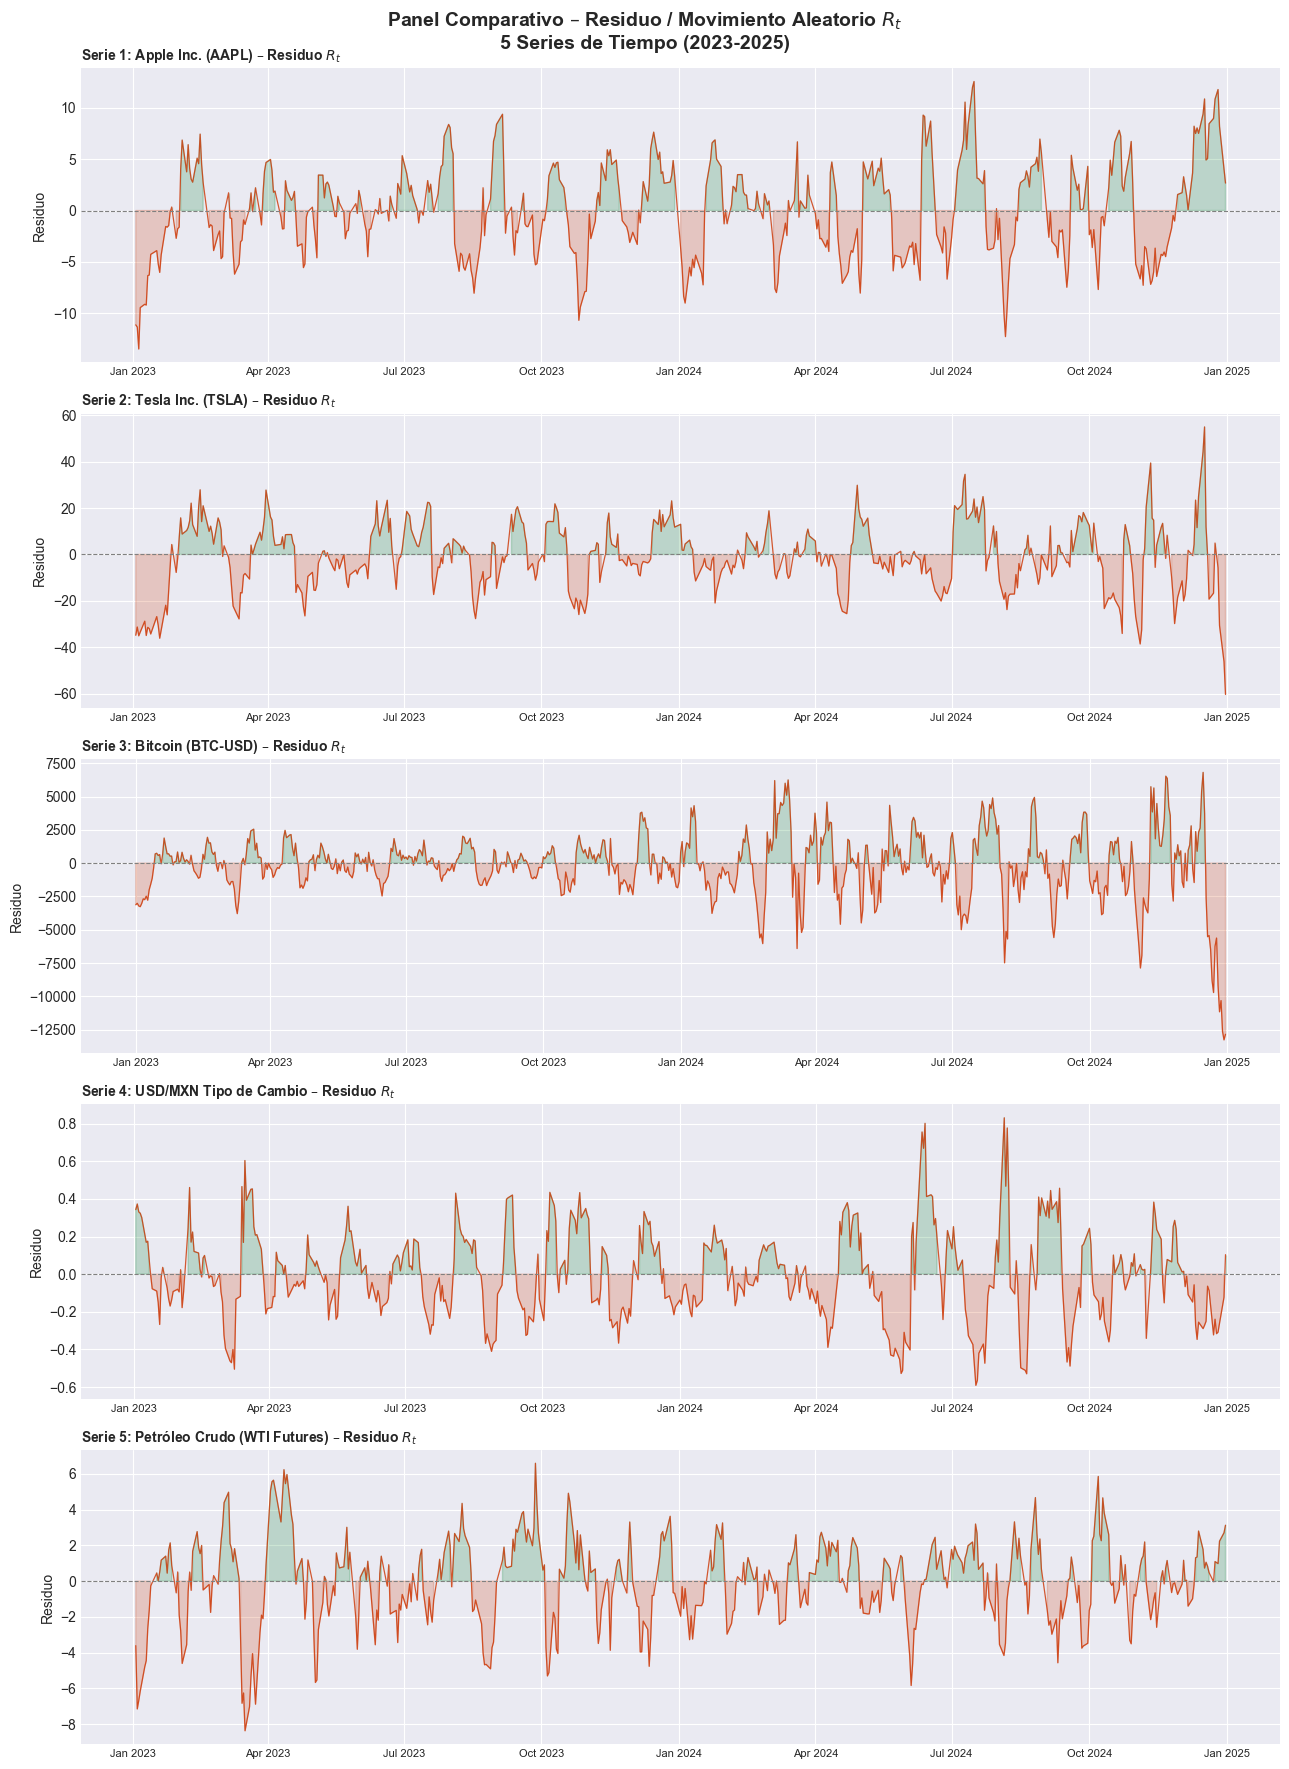

Panel de residuos guardado: panel_residuos.png


In [11]:
fig, axes = plt.subplots(5, 1, figsize=(13, 18), sharex=False)
fig.suptitle(
    'Panel Comparativo – Residuo / Movimiento Aleatorio $R_t$\n'
    '5 Series de Tiempo (2023-2025)',
    fontsize=14, fontweight='bold'
)

for i, (ticker, nombre, color, res, ax) in enumerate(
        zip(tickers_l, nombres_l, colores, results_l, axes)):
    resid = res.resid.dropna()
    ax.plot(resid.index, resid.values, color='#cc3300',
            linewidth=0.9, alpha=0.8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.fill_between(resid.index, resid.values, 0,
                    where=(resid.values > 0), color='#00802b', alpha=0.2)
    ax.fill_between(resid.index, resid.values, 0,
                    where=(resid.values < 0), color='#cc3300', alpha=0.2)
    ax.set_title(f'Serie {i+1}: {nombre} – Residuo $R_t$',
                 fontsize=10, fontweight='bold', loc='left')
    ax.set_ylabel('Residuo')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('panel_residuos.png', dpi=130, bbox_inches='tight')
plt.show()
print('Panel de residuos guardado: panel_residuos.png')

---
## Paso 8: Panel comparativo de Regresión Lineal – 5 Series

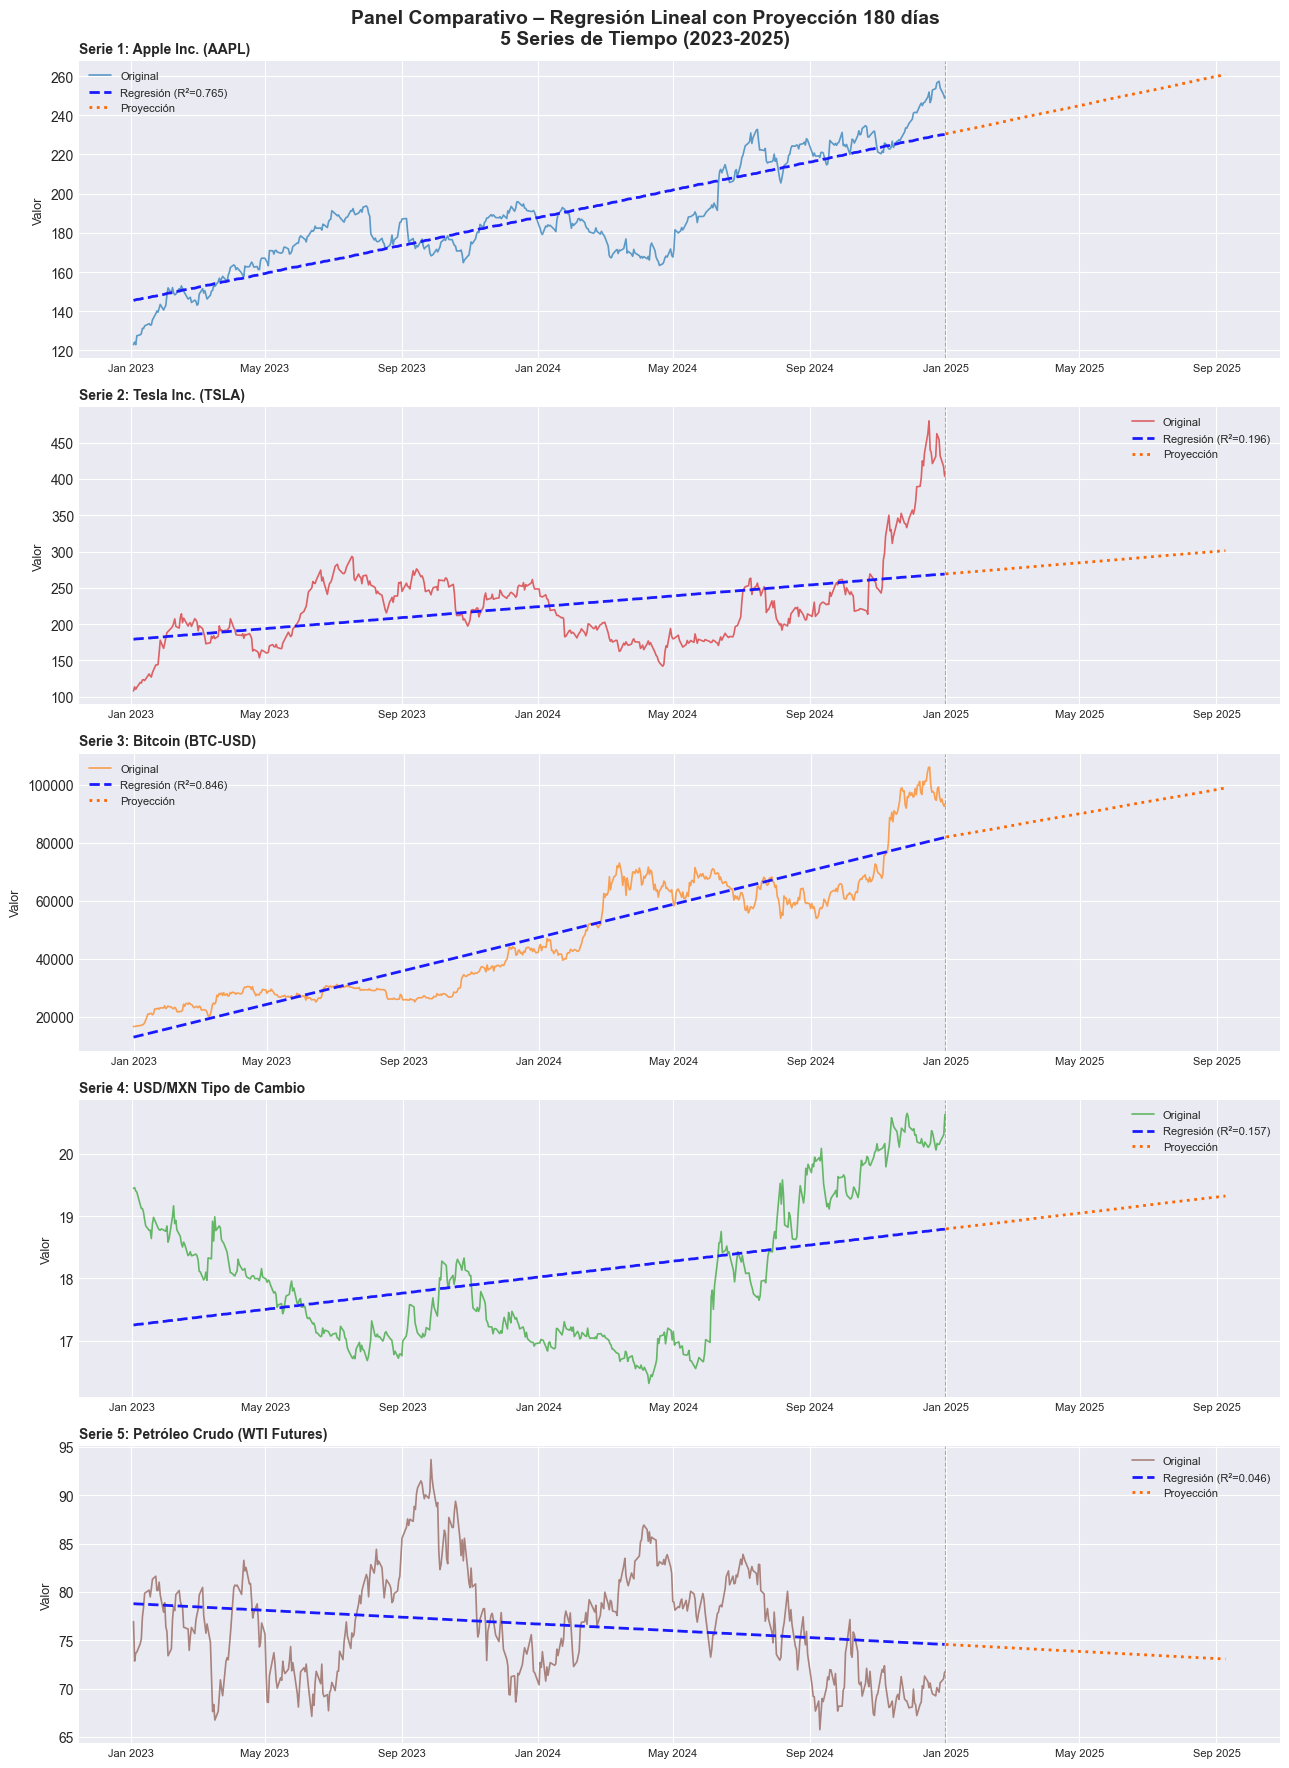

Panel de regresión guardado: panel_regresion.png


In [12]:
modelos_l = [lr_aapl, lr_tsla, lr_btc, lr_mxn, lr_oil]

fig, axes = plt.subplots(5, 1, figsize=(13, 18), sharex=False)
fig.suptitle(
    'Panel Comparativo – Regresión Lineal con Proyección 180 días\n'
    '5 Series de Tiempo (2023-2025)',
    fontsize=14, fontweight='bold'
)

for i, (ticker, nombre, color, modelo, ax) in enumerate(
        zip(tickers_l, nombres_l, colores, modelos_l, axes)):
    serie = datos[ticker].dropna()
    X = np.arange(len(serie)).reshape(-1, 1)
    y = serie.values
    y_pred = modelo.predict(X)

    X_fut = np.arange(len(serie), len(serie) + 180).reshape(-1, 1)
    y_fut = modelo.predict(X_fut)
    fechas_futuras = pd.bdate_range(
        start=serie.index[-1] + pd.Timedelta(days=1), periods=180)

    r2 = r2_score(y, y_pred)

    ax.plot(serie.index, y, color=color, linewidth=1.2,
            alpha=0.7, label='Original')
    ax.plot(serie.index, y_pred, color='#1a1aff', linewidth=2,
            linestyle='--', label=f'Regresión (R²={r2:.3f})')
    ax.plot(fechas_futuras[:len(y_fut)], y_fut, color='#ff6600',
            linewidth=2, linestyle=':', label='Proyección')
    ax.axvline(serie.index[-1], color='gray',
               linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(f'Serie {i+1}: {nombre}', fontsize=10,
                 fontweight='bold', loc='left')
    ax.set_ylabel('Valor', fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('panel_regresion.png', dpi=130, bbox_inches='tight')
plt.show()
print('Panel de regresión guardado: panel_regresion.png')

---
# CONCLUSIONES

En esta práctica se implementaron dos técnicas fundamentales de análisis de series de tiempo aplicadas a las 5 series financieras de la Práctica 32.

## Descomposición de Componentes

Mediante el modelo **aditivo** (`seasonal_decompose` de `statsmodels`) se extrajo cada componente:

- **Tendencia ($T_t$):** Todas las series presentan una tendencia identificable. AAPL y BTC muestran tendencias **alcistas** sostenidas, TSLA muestra alta variabilidad de tendencia, USD/MXN refleja **depreciación gradual** del peso, y el petróleo WTI presenta una tendencia **descendente** o lateral.

- **Estacionalidad ($S_t$):** Se detectan patrones repetitivos mensuales (período=30) de amplitud moderada en todas las series. Esta componente es más pronunciada en activos con fuerte influencia de calendarios de reportes trimestrales (AAPL, TSLA).

- **Ciclicidad ($C_t$):** Estimada mediante media móvil de 60 días sobre la tendencia, captura fluctuaciones de mediano plazo asociadas a ciclos económicos y de mercado.

- **Movimiento Aleatorio ($R_t$):** El residuo captura shocks exógenos (noticias, eventos geopolíticos). Bitcoin presenta los residuos más volátiles, mientras que el USD/MXN muestra picos puntuales relacionados con eventos políticos.

## Regresión Lineal

La regresión lineal modela la tendencia de largo plazo con la ecuación: $\hat{Y}_t = \beta_0 + \beta_1 \cdot t$

- Las series con **mayor R²** (Apple, Bitcoin) indican que la tendencia lineal explica bien la dirección general del precio.
- Las series con **menor R²** (Tesla, Petróleo) muestran mayor irregu­laridad y son menos adecuadas para proyecciones lineales.
- La **proyección a 180 días** proporciona una estimación de referencia de largo plazo, aunque para predicciones precisas se recomienda complementar con modelos ARIMA, SARIMA o redes neuronales LSTM.

---
## REFERENCIAS

1. Yahoo Finance (2026). https://finance.yahoo.com/  
2. yfinance Documentation (2026). https://pypi.org/project/yfinance/  
3. Hyndman, R.J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3rd ed. OTexts.  
4. Seabold, S. & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proc. 9th Python in Science Conf.*  
5. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.  
6. McKinney, W. (2022). *Python for Data Analysis*, 3rd ed. O'Reilly Media.